In [1]:
%load_ext autoreload
%autoreload 2

import warnings

warnings.filterwarnings("ignore")

# Comparison to UMAP

Glass box UMAP and standard UMAP both produce low-dimensional embeddings of high-dimensional data, but they arrive there in different ways. This notebook walks through how they differ, why neither produces a unique embedding from a given dataset, and how the two methods compare in practice across datasets.

## How glass box UMAP differs from standard UMAP

Standard UMAP is **non-parametric**: it builds a fuzzy neighbor graph from the input points and then optimizes the coordinates of those exact points via stochastic gradient descent on the UMAP loss. The output is a table of coordinates.

Glass box UMAP is **parametric**: it trains a small neural network to map inputs to embedding coordinates by minimizing the same UMAP loss on the same fuzzy graph. The embedding is whatever that trained network produces when the data is passed through it. The glass box encoder is built from [PReLU activations and zero-bias linear layers](../resources/methodology.md#why-this-property-holds), which makes it locally linear, and that structure is what lets {meth}`compute_contributions <glass_box_umap.GlassBoxUMAP.compute_contributions>` return exact per-sample attributions of each input feature to each embedding coordinate.

Both methods minimize the same loss, but they don't produce the same embeddings. So a natural question is: how closely does glass box UMAP track standard UMAP?

## Both methods are stochastic

Neither method is deterministic. Here are 8 UMAP runs with different initialization seeds:

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from umap import UMAP

from glass_box_umap import GlassBoxUMAP

X_raw, y = load_wine(return_X_y=True)
X = StandardScaler().fit_transform(np.asarray(X_raw)).astype(np.float32)

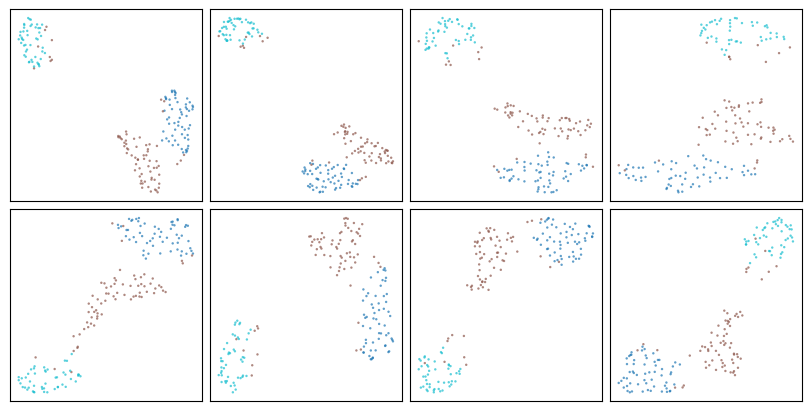

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(8, 4), constrained_layout=True)
for seed, ax in enumerate(axes.flat):
    emb = UMAP(random_state=seed).fit_transform(X)
    ax.scatter(emb[:, 0], emb[:, 1], c=y, cmap="tab10", s=3, alpha=0.7, linewidths=0)
    ax.set(xticks=[], yticks=[])
plt.show()

And 8 glass box UMAP runs:

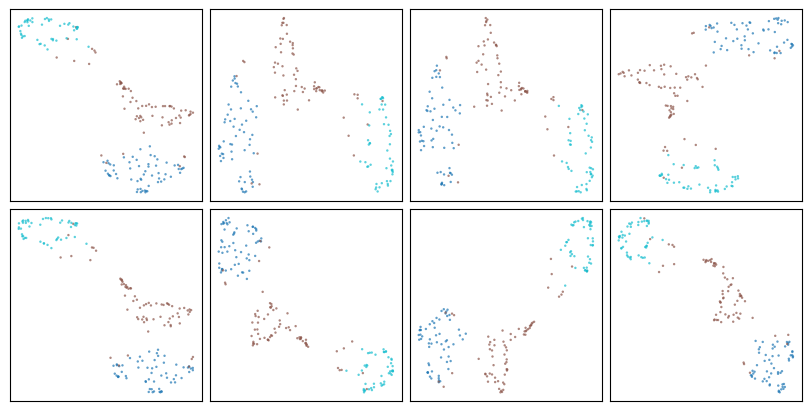

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(8, 4), constrained_layout=True)
for seed, ax in enumerate(axes.flat):
    emb = GlassBoxUMAP(epochs=300, random_state=seed, quiet=True).fit_transform(X)
    ax.scatter(emb[:, 0], emb[:, 1], c=y, cmap="tab10", s=3, alpha=0.7, linewidths=0)
    ax.set(xticks=[], yticks=[])
plt.show()

So "do glass box UMAP embeddings match standard UMAP embeddings?" depends entirely on which run of each you compare. The most we can ask is how the two methods compare *as distributions over seeds*: how close can they get, and how far can they drift apart?

## Experiment

For each dataset, we fit standard UMAP 10 times and glass box UMAP 10 times (seeds 0–9), score every (UMAP, glass box UMAP) pair on a local-distance metric, and report the **best** and **worst** pair across the 10 × 10 grid. The best shows how close the two methods can get when seeds align favorably while the worst is shown for posterity.

### The metric

A naive coordinate-wise comparison would punish glass box UMAP for arbitrary rotations and reflections. Instead, we score agreement on inter-point distances. For each (UMAP, glass box UMAP) pair:

1. Standardize features and fit both methods.
2. Normalize each embedding so x and y both lie in [0, 1].
3. Compute pairwise distances within each embedding.
4. Take the smallest 25% of distances in each (the "local" pairs in that embedding).
5. Take the union of those two index sets, so a pair counts if it's local in *either* embedding.
6. Report MSE between the two distance vectors on that union.

The union catches disagreement from both sides: a pair that's tight in one embedding but spread out in the other is included and penalized. Far-apart pairs are deliberately excluded because UMAP's inter-cluster spacing carries little meaning, so we don't want to score on it.

For visualization only, the glass box panel is rotated and reflected to match its UMAP counterpart via orthogonal Procrustes. This step only affects how the panels look side-by-side.

## Dataset and helper code

In [5]:
import json
import urllib.request
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from numpy.typing import NDArray
from scipy.spatial.distance import pdist
from sklearn.datasets import (
    fetch_20newsgroups,
    fetch_openml,
    load_breast_cancer,
    load_digits,
    load_iris,
    load_wine,
    make_swiss_roll,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from umap import UMAP

from glass_box_umap import GlassBoxUMAP

N_RUNS = 10
LOCAL_FRAC = 0.25


@dataclass
class Dataset:
    name: str
    X: NDArray
    labels: NDArray
    label_name: str
    cmap: str = "tab10"


@dataclass
class ComparisonResult:
    dataset: Dataset
    umap_embeddings: list[NDArray]
    gb_embeddings: list[NDArray]
    mse: NDArray


def normalize_embedding(emb: NDArray) -> NDArray:
    out = np.copy(emb)
    for d in range(out.shape[1]):
        col = out[:, d]
        out[:, d] = (col - col.min()) / (col.max() - col.min())
    return out


def align_to(target: NDArray, source: NDArray) -> NDArray:
    """Return source translated and orthogonally transformed to align with target.

    Solves the orthogonal Procrustes problem for indexed correspondences
    (row i of target matches row i of source). Allows rotation and reflection
    but not scaling. Both embeddings are already normalized, and rescaling
    would distort the visual size match.

    Used for plotting only. The comparison metric is rotation-invariant
    and does not depend on this.
    """
    t_mean = target.mean(axis=0)
    s_mean = source.mean(axis=0)
    t_c = target - t_mean
    s_c = source - s_mean
    U, _, Vt = np.linalg.svd(s_c.T @ t_c)
    return s_c @ (U @ Vt) + t_mean


def local_distance_mse(a: NDArray, b: NDArray, frac: float = LOCAL_FRAC) -> float:
    """MSE of pairwise distances, restricted to the union of each embedding's local pairs.

    "Local" = the smallest fraction of pairwise distances within an embedding. The union
    catches disagreement from either direction: a pair that's local in only one embedding
    is still included.
    """
    d_a = pdist(a)
    d_b = pdist(b)
    k = max(1, min(int(frac * len(d_a)), len(d_a) - 1))
    idx_a = np.argpartition(d_a, k)[:k]
    idx_b = np.argpartition(d_b, k)[:k]
    union = np.union1d(idx_a, idx_b)
    diff = d_a[union] - d_b[union]
    return float(np.mean(diff ** 2))


def run_comparison(dataset: Dataset) -> ComparisonResult:
    umap_embeddings: list[NDArray] = []
    for seed in range(N_RUNS):
        emb = UMAP(random_state=seed).fit_transform(dataset.X)
        umap_embeddings.append(normalize_embedding(np.asarray(emb)))

    gb_embeddings: list[NDArray] = []
    for seed in range(N_RUNS):
        emb = GlassBoxUMAP(epochs=200, random_state=seed, quiet=True).fit_transform(dataset.X)
        gb_embeddings.append(normalize_embedding(np.asarray(emb)))

    mse = np.zeros((N_RUNS, N_RUNS))
    for i, u in enumerate(umap_embeddings):
        for j, g in enumerate(gb_embeddings):
            mse[i, j] = local_distance_mse(u, g)

    return ComparisonResult(
        dataset=dataset,
        umap_embeddings=umap_embeddings,
        gb_embeddings=gb_embeddings,
        mse=mse,
    )


def plot_best_worst(result: ComparisonResult) -> None:
    best_i, best_j = np.unravel_index(np.argmin(result.mse), result.mse.shape)
    worst_i, worst_j = np.unravel_index(np.argmax(result.mse), result.mse.shape)

    best_umap = result.umap_embeddings[best_i]
    best_gb = align_to(best_umap, result.gb_embeddings[best_j])
    worst_umap = result.umap_embeddings[worst_i]
    worst_gb = align_to(worst_umap, result.gb_embeddings[worst_j])

    fig = plt.figure(figsize=(13, 3.5))
    gs = fig.add_gridspec(
        1, 5,
        width_ratios=[1, 1, 0.15, 1, 1],
        wspace=0.08,
        left=0.02, right=0.98, top=0.78, bottom=0.04,
    )
    axes = [fig.add_subplot(gs[0, c]) for c in (0, 1, 3, 4)]

    panels = [
        (best_umap, f"UMAP (seed {best_i})"),
        (best_gb, f"glass box UMAP (seed {best_j})"),
        (worst_umap, f"UMAP (seed {worst_i})"),
        (worst_gb, f"glass box UMAP (seed {worst_j})"),
    ]
    labels = result.dataset.labels
    cmap = result.dataset.cmap
    pad = 0.04
    for pair_idx in (0, 2):
        u, g = panels[pair_idx][0], panels[pair_idx + 1][0]
        xs = np.concatenate([u[:, 0], g[:, 0]])
        ys = np.concatenate([u[:, 1], g[:, 1]])
        x_lo, x_hi = float(xs.min()) - pad, float(xs.max()) + pad
        y_lo, y_hi = float(ys.min()) - pad, float(ys.max()) + pad
        for ax_idx in (pair_idx, pair_idx + 1):
            ax = axes[ax_idx]
            emb, subtitle = panels[ax_idx]
            ax.scatter(emb[:, 0], emb[:, 1], c=labels, cmap=cmap, s=8, alpha=0.75, linewidths=0)
            ax.set_title(subtitle, fontsize=11, pad=4)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_aspect("equal")
            ax.set_xlim(x_lo, x_hi)
            ax.set_ylim(y_lo, y_hi)

    fig.canvas.draw()
    bbox0 = axes[0].get_position()
    bbox1 = axes[1].get_position()
    bbox2 = axes[2].get_position()
    bbox3 = axes[3].get_position()
    best_x = (bbox0.x0 + bbox1.x1) / 2
    worst_x = (bbox2.x0 + bbox3.x1) / 2
    title_y = max(bbox0.y1, bbox1.y1, bbox2.y1, bbox3.y1) + 0.08

    fig.text(
        best_x, title_y, "Best match",
        ha="center", va="bottom", fontsize=12, fontweight="bold",
    )
    fig.text(
        worst_x, title_y, "Worst match",
        ha="center", va="bottom", fontsize=12, fontweight="bold",
    )
    fig.suptitle(
        f"{result.dataset.name}  ·  colored by {result.dataset.label_name}",
        fontsize=22,
        fontweight="bold",
        y=0.99,
    )
    plt.show()


def standardize(X_raw: NDArray) -> NDArray:
    return StandardScaler().fit_transform(X_raw).astype(np.float32)

In [6]:
def load_iris_dataset() -> Dataset:
    X_raw, y = load_iris(return_X_y=True)
    return Dataset(
        name="Iris",
        X=standardize(np.asarray(X_raw)),
        labels=np.asarray(y),
        label_name="species",
    )


def load_wine_dataset() -> Dataset:
    X_raw, y = load_wine(return_X_y=True)
    return Dataset(
        name="Wine",
        X=standardize(np.asarray(X_raw)),
        labels=np.asarray(y),
        label_name="cultivar",
    )


def load_breast_cancer_dataset() -> Dataset:
    X_raw, y = load_breast_cancer(return_X_y=True)
    return Dataset(
        name="Breast cancer",
        X=standardize(np.asarray(X_raw)),
        labels=np.asarray(y),
        label_name="diagnosis",
    )


def load_digits_dataset() -> Dataset:
    X_raw, y = load_digits(return_X_y=True)
    return Dataset(
        name="Digits",
        X=standardize(np.asarray(X_raw)),
        labels=np.asarray(y),
        label_name="digit",
    )


def load_penguins_dataset() -> Dataset:
    penguins = sns.load_dataset("penguins").dropna().reset_index(drop=True)
    numeric_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
    species_to_int = {s: i for i, s in enumerate(sorted(penguins["species"].unique()))}
    return Dataset(
        name="Penguins",
        X=standardize(penguins[numeric_cols].to_numpy()),
        labels=np.array([species_to_int[s] for s in penguins["species"]]),
        label_name="species",
    )


def load_mnist_dataset() -> Dataset:
    mnist = fetch_openml("mnist_784", version=1, as_frame=False)
    X_raw = np.asarray(mnist.data)[:1000]
    y = np.asarray(mnist.target).astype(int)[:1000]
    return Dataset(
        name="MNIST",
        X=standardize(X_raw),
        labels=y,
        label_name="digit",
    )


def load_fashion_mnist_dataset() -> Dataset:
    fashion = fetch_openml("Fashion-MNIST", version=1, as_frame=False)
    X_raw = np.asarray(fashion.data)[:1000]
    y = np.asarray(fashion.target).astype(int)[:1000]
    return Dataset(
        name="Fashion MNIST",
        X=standardize(X_raw),
        labels=y,
        label_name="garment",
    )


def load_newsgroups_dataset() -> Dataset:
    raw = fetch_20newsgroups(subset="all")
    docs = raw.data[:1000]
    y = np.asarray(raw.target[:1000])
    X = TfidfVectorizer(max_features=5000).fit_transform(docs).toarray().astype(np.float32)
    return Dataset(
        name="20 Newsgroups",
        X=X,
        labels=y,
        label_name="newsgroup",
        cmap="tab20",
    )


def load_swissroll_dataset() -> Dataset:
    X_raw, t = make_swiss_roll(n_samples=1000, random_state=0)
    return Dataset(
        name="Swiss Roll",
        X=standardize(np.asarray(X_raw)),
        labels=np.asarray(t),
        label_name="manifold position",
        cmap="turbo",
    )

## Results

The two left panels are the closest pair of (UMAP, glass box UMAP) embeddings found across the 10x10 seed grid. The two right panels are the farthest.

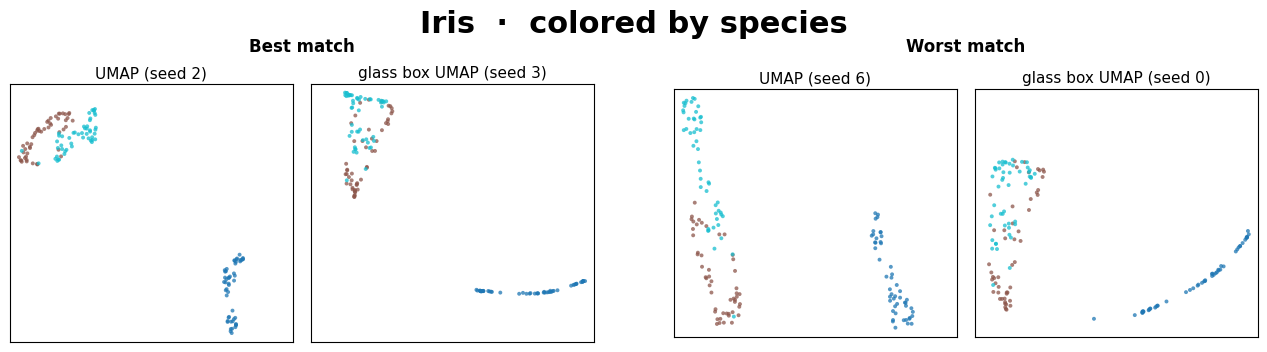

In [7]:
plot_best_worst(run_comparison(load_iris_dataset()))

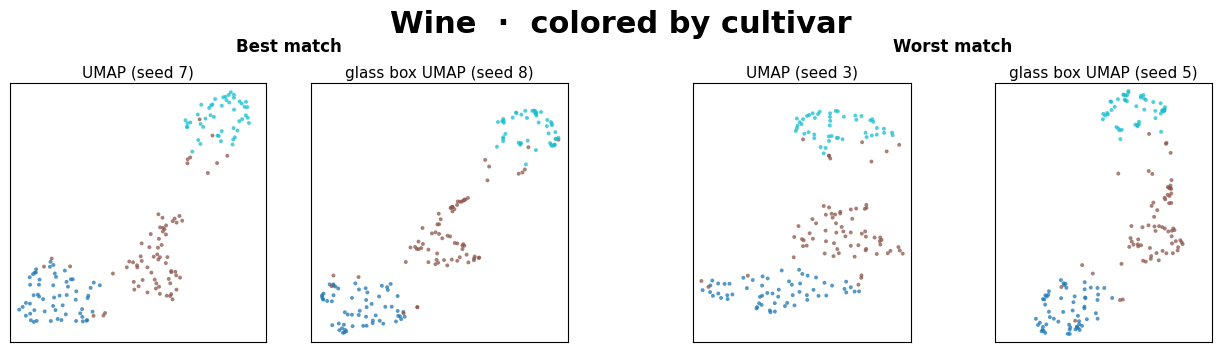

In [8]:
plot_best_worst(run_comparison(load_wine_dataset()))

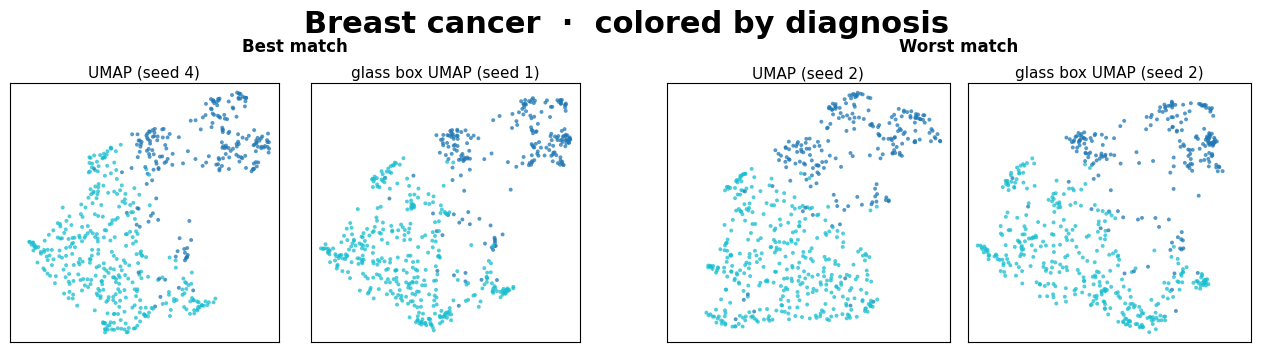

In [9]:
plot_best_worst(run_comparison(load_breast_cancer_dataset()))

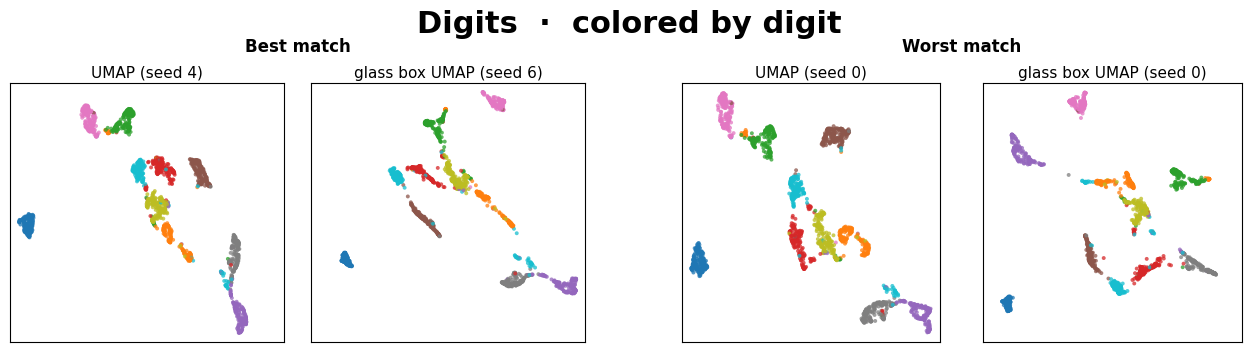

In [10]:
plot_best_worst(run_comparison(load_digits_dataset()))

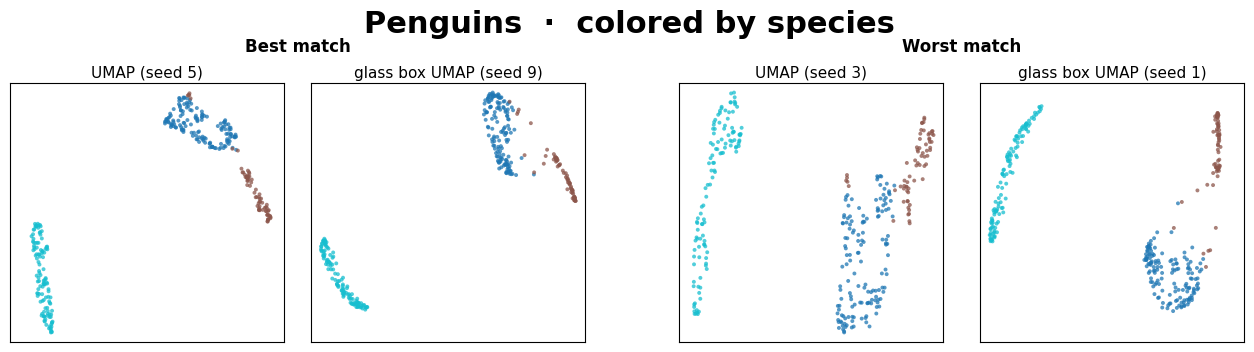

In [11]:
plot_best_worst(run_comparison(load_penguins_dataset()))

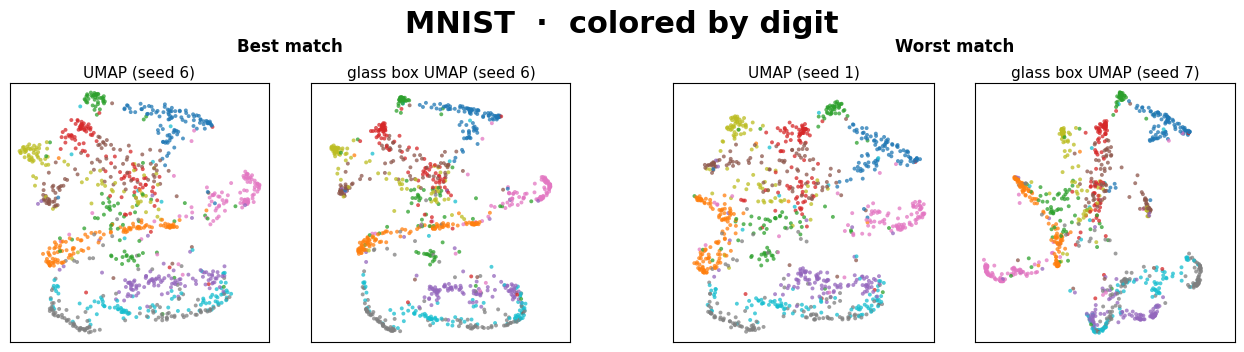

In [12]:
plot_best_worst(run_comparison(load_mnist_dataset()))

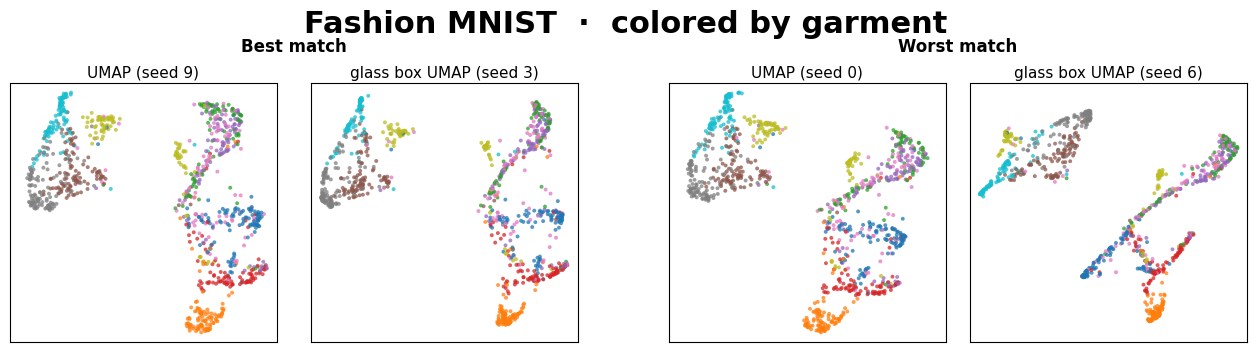

In [13]:
plot_best_worst(run_comparison(load_fashion_mnist_dataset()))

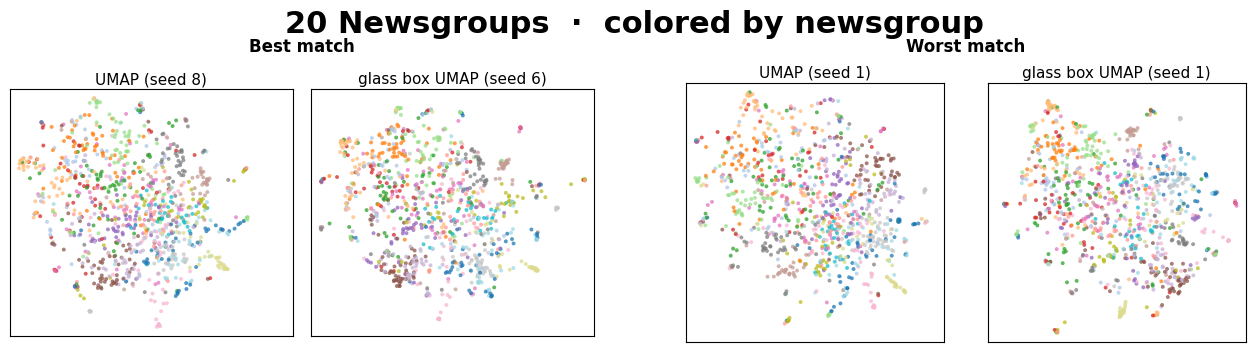

In [14]:
plot_best_worst(run_comparison(load_newsgroups_dataset()))

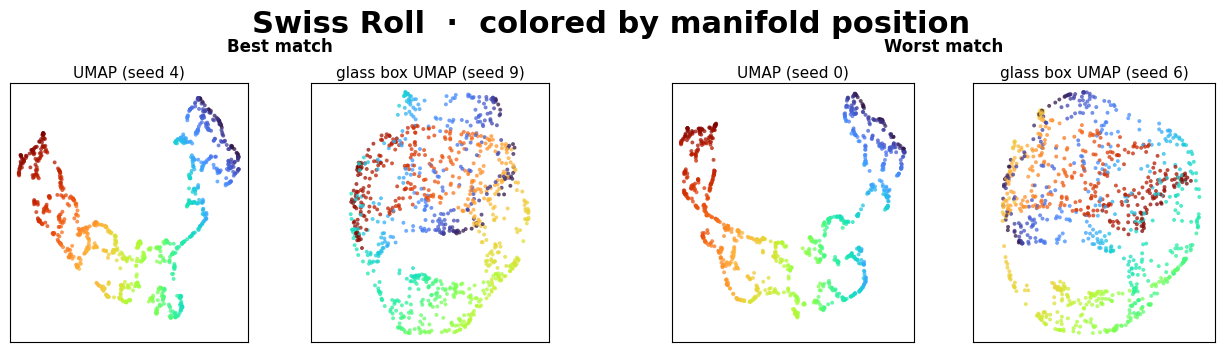

In [15]:
plot_best_worst(run_comparison(load_swissroll_dataset()))

:::{warning}
The swiss roll dataset is a 2D sheet of data that's been rolled up into a spiral in 3D. In other words, the data lives on a curved 2D surface, even though it occupies 3D space. It is a common benchmarking dataset used for assessing dimensionality reduction techniques, with the goal being to produce an embedding that unrolls the sheet to lay flat. Roughly speaking, it should look like a rectangular or roughly flat 2D cloud where color goes smoothly from one end to the other.

Here, we see that the default UMAP parameters partially succeed in unrolling the Swiss roll (albeit into a fragmented "horseshoe" shape rather than a rectangle). However, the more important point is that glass box UMAP, with its default parameters, is **unable to recapitulate UMAP embedding**. If you're interested in this failure mode and how to remedy it, see [Embedding Refinement](embedding_refinement.ipynb) for a full breakdown.
:::

## Takeaways

In all but one of these datasets (see above note), the best embedding pair is very similar visually. Within just a small grid of seed comparisons, two methods that work very differently routinely converge on the same manifold.

The worst pairs always yield different, yet sensible-looking embeddings. We interpret this to mean that the two methods simply picked structurally different layouts from their seed spaces, which is the same kind of variance we expect between two standard UMAP runs.

The main takeaway isn't that glass box UMAP matches standard UMAP exactly, since neither method matches itself across seeds. It's that two methods with very different inductive biases produce embeddings from the same family, and that glass box UMAP brings exact feature attributions along with it.

In general, we encourage users to sanity check glass box UMAP embeddings against standard UMAP embeddings.